<a href="https://colab.research.google.com/github/Amitabh-Phule/Deep-Learning/blob/main/DL_Exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Imports & Epoch Setup**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Set number of epochs
EPOCHS = 20  # Change this to experiment


### **Load & Preprocess MNIST**

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Flatten 28x28 → 784
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### **Helper Function to Compile & Train Models**

In [5]:
def train_model(model, epochs=EPOCHS):
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=epochs,
        batch_size=128,
        verbose=1
    )
    return history


### **Baseline Model (No Regularization)**

In [6]:
baseline_model = Sequential([
    Dense(512, activation="relu", input_shape=(784,)),
    Dense(512, activation="relu"),
    Dense(10, activation="softmax")
])

history_baseline = train_model(baseline_model)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8828 - loss: 0.3990 - val_accuracy: 0.9706 - val_loss: 0.0895
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9745 - loss: 0.0816 - val_accuracy: 0.9738 - val_loss: 0.0795
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9844 - loss: 0.0498 - val_accuracy: 0.9775 - val_loss: 0.0755
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9884 - loss: 0.0353 - val_accuracy: 0.9771 - val_loss: 0.0745
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9925 - loss: 0.0242 - val_accuracy: 0.9825 - val_loss: 0.0660
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9937 - loss: 0.0188 - val_accuracy: 0.9739 - val_loss: 0.1009
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9933 - loss: 0.0183 - val_accuracy: 0.9792 - val_loss: 0.0812
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9961 - loss: 0.0116 - val_a

### **Dropout Model**

In [7]:
dropout_model = Sequential([
    Dense(512, activation="relu", input_shape=(784,)),
    Dropout(0.5),
    Dense(512, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

history_dropout = train_model(dropout_model)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8126 - loss: 0.5885 - val_accuracy: 0.9610 - val_loss: 0.1247
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9494 - loss: 0.1679 - val_accuracy: 0.9732 - val_loss: 0.0870
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9626 - loss: 0.1245 - val_accuracy: 0.9750 - val_loss: 0.0838
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9674 - loss: 0.1054 - val_accuracy: 0.9778 - val_loss: 0.0749
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9717 - loss: 0.0941 - val_accuracy: 0.9788 - val_loss: 0.0692
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9735 - loss: 0.0834 - val_accuracy: 0.9813 - val_loss: 0.0625
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9767 - loss: 0.0744 - val_accuracy: 0.9800 - val_loss: 0.0677
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9774 - loss: 0.0735 - 

### **L2 Regularization Model**

In [8]:
l2_model = Sequential([
    Dense(512, activation="relu", kernel_regularizer=l2(0.001), input_shape=(784,)),
    Dense(512, activation="relu", kernel_regularizer=l2(0.001)),
    Dense(10, activation="softmax")
])

history_l2 = train_model(l2_model)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8803 - loss: 1.0504 - val_accuracy: 0.9608 - val_loss: 0.3505
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9629 - loss: 0.3165 - val_accuracy: 0.9658 - val_loss: 0.2418
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9703 - loss: 0.2286 - val_accuracy: 0.9699 - val_loss: 0.2154
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9723 - loss: 0.2008 - val_accuracy: 0.9704 - val_loss: 0.1937
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9746 - loss: 0.1823 - val_accuracy: 0.9745 - val_loss: 0.1844
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9780 - loss: 0.1682 - val_accuracy: 0.9731 - val_loss: 0.1774
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9773 - loss: 0.1606 - val_accuracy: 0.9746 - val_loss: 0.1668
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9819 - loss: 0.1440 - 

### **Batch Normalization Model**

In [9]:
bn_model = Sequential([
    Dense(512, input_shape=(784,)),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    Dense(512),
    BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    Dense(10, activation="softmax")
])

history_bn = train_model(bn_model)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.9064 - loss: 0.3021 - val_accuracy: 0.9551 - val_loss: 0.1463
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9805 - loss: 0.0626 - val_accuracy: 0.9689 - val_loss: 0.1008
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9880 - loss: 0.0378 - val_accuracy: 0.9750 - val_loss: 0.0755
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9920 - loss: 0.0262 - val_accuracy: 0.9773 - val_loss: 0.0761
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9919 - loss: 0.0230 - val_accuracy: 0.9773 - val_loss: 0.0773
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9944 - loss: 0.0173 - val_accuracy: 0.9799 - val_loss: 0.0797
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9949 - loss: 0.0158 - val_accuracy: 0.9800 - val_loss: 0.0735
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9947 - loss: 0.0154 - v

### **Plot Validation Loss Comparison**

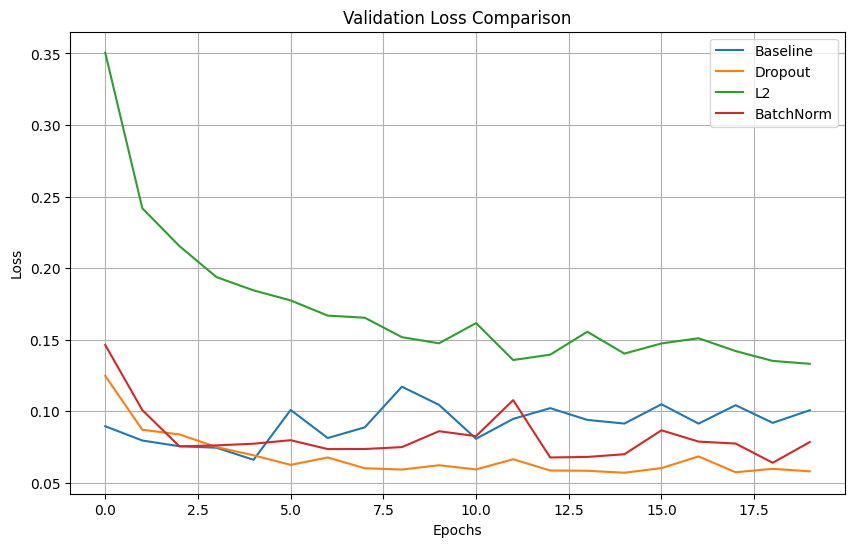

In [10]:
plt.figure(figsize=(10,6))
plt.plot(history_baseline.history["val_loss"], label="Baseline")
plt.plot(history_dropout.history["val_loss"], label="Dropout")
plt.plot(history_l2.history["val_loss"], label="L2")
plt.plot(history_bn.history["val_loss"], label="BatchNorm")
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


### **Plot Validation Accuracy Comparison**

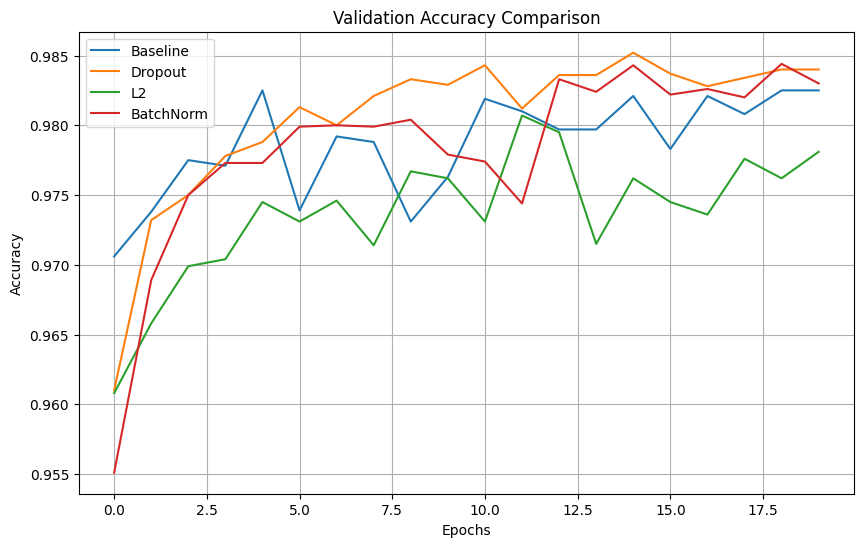

In [11]:
plt.figure(figsize=(10,6))
plt.plot(history_baseline.history["val_accuracy"], label="Baseline")
plt.plot(history_dropout.history["val_accuracy"], label="Dropout")
plt.plot(history_l2.history["val_accuracy"], label="L2")
plt.plot(history_bn.history["val_accuracy"], label="BatchNorm")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
